In [1]:
import sisl
import numpy as np
from TimedependentTransport.Structures import structs
import matplotlib.pyplot as plt
from ase.visualize import view
from siesta_python.siesta_python import SiP
from GrainBoundaryModule.GrainBoundaryFunctions import more_screening, buffer_idx
import matplotlib.pyplot as plt
from TimedependentTransport.TimedependentTransport import TD_Transport
from TimedependentTransport.TimedependentTransport import AdaptiveRK4  as RK4
%matplotlib inline
plt.rcParams['figure.figsize'] = [15,10]

(-33.1315258868921, 69.82693504223299, -6.641812420669574, 7.134651317669574)

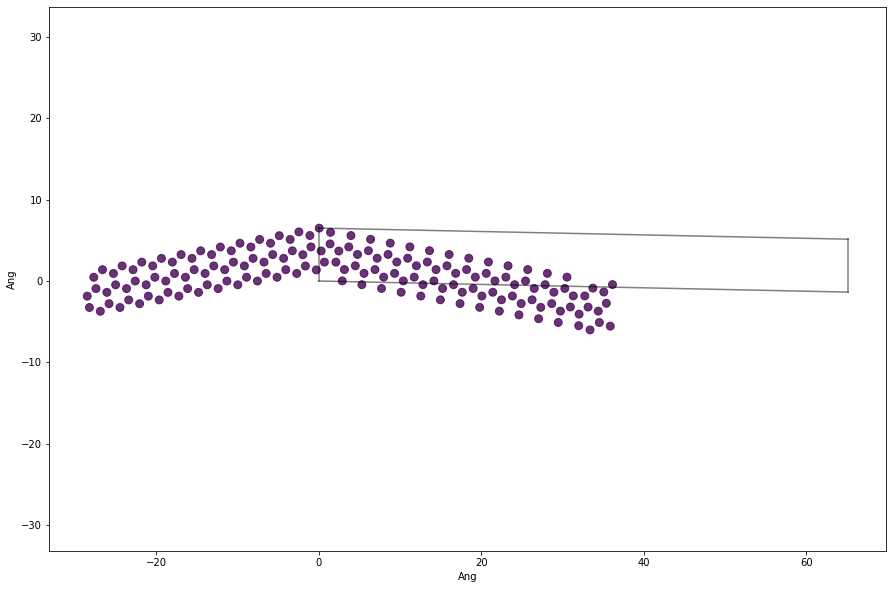

In [2]:
i = 0#40      # 13,15 
d, em, ep, n = structs[i]
d, em, ep = more_screening(d, em, ep, 0,0)
bidx = buffer_idx(d, ep)
#view(d.toASE())
old_xyz = d.xyz.copy()

ky = 20
sisl.plot(d.tile(1,1))
plt.axis('equal')
#em = em.tile(2,0)


Directory called EM already exists! Remove it? (y/reuse/n)
 set struct
done
No atoms overlapping within 0.3 Å!
self.pos is reduced coordinates, self.pos_real_space is actual coordinates!

Directory called EP already exists! Remove it? (y/reuse/n)
 set struct
done
No atoms overlapping within 0.3 Å!
self.pos is reduced coordinates, self.pos_real_space is actual coordinates!

Directory called Device already exists! Remove it? (y/reuse/n)
 set struct
done
No atoms overlapping within 0.3 Å!
self.pos is reduced coordinates, self.pos_real_space is actual coordinates!



/home/aleksander/.local/lib/python3.9/site-packages/seekpath/hpkot/__init__.py:350: EdgeCaseWarning: aP lattice, but the k_alpha3 angle is almost equal to 90 degrees
  warnings.warn(
/home/aleksander/.local/lib/python3.9/site-packages/seekpath/hpkot/__init__.py:360: EdgeCaseWarning: aP lattice, but the k_gamma3 angle is almost equal to 90 degrees
  warnings.warn(


[[25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60], [109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144]]


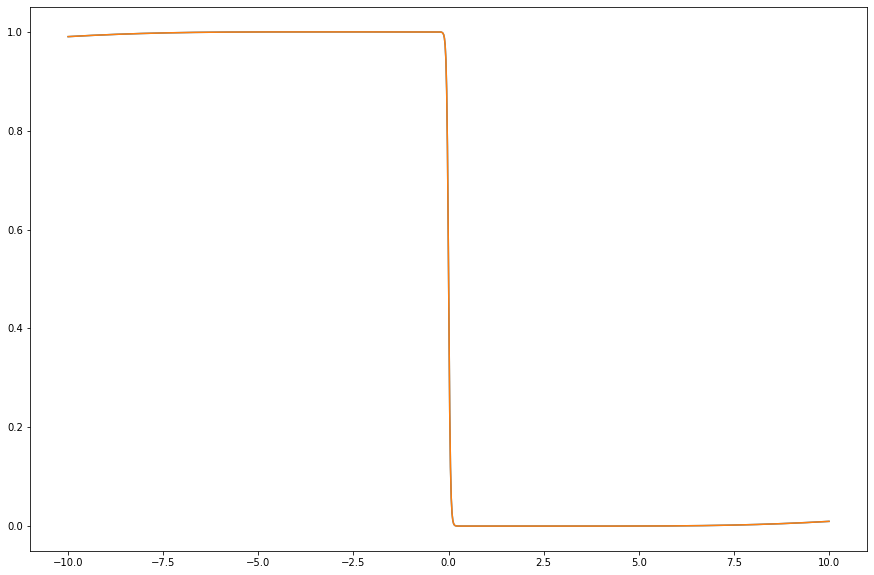

In [3]:
eta = 1e-1
line = np.vstack([np.linspace(-3,3,65) + 1j * eta]*2)

G = TD_Transport([em, ep], d, kT_i = [0.025, 0.025])
G.Make_Contour(line, 15, pole_mode = 'JieHu2011')

G.Electrodes( semi_infs = ['-a1', '+a1'] , kp = [[40,ky,1],[40,ky,1]])
G.make_device(k = [1,ky,1], k_tbtrans = [1,5,1])
#G.run_electrodes()
#G.run_device()


Normal plot


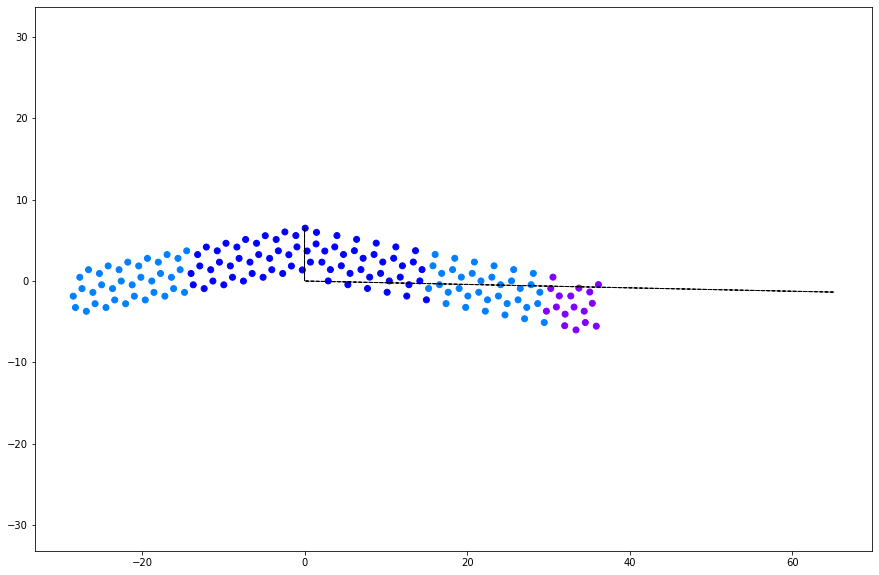

In [4]:
def buffer_cond(r):
    if (np.linalg.norm(r - old_xyz[bidx], axis = 1)<1e-2).any():
        return True
    return False
G.Device.set_buffer_atoms(buffer_cond)
G.Device.Visualise()

In [5]:
G.run_electrodes()
G.run_device(morestuff = ['TS.Hartree.Fix -A'], where = 'TS_TBT')
G.read_data(sub_orbital = [4*i+2 for i in range(d.na - em.na - ep.na - len(G.Device.buffer_atoms))])

Running Siesta electrode calculation in Directory: EM!



Job completed


Running Siesta electrode calculation in Directory: EP!



Job completed


Running TranSiesta calculation in Directory: Device!



Job completed


Running Siesta-analyse in Directory:Device!



Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG


Running TB-Trans in Directory: Device!


 Building ES - H - Self Energies 


 Overlap Included!




 This code means the particular orbitals that have been subbed on (if any)

Calculating matrix elements of inverse



/usr/lib/python3/dist-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


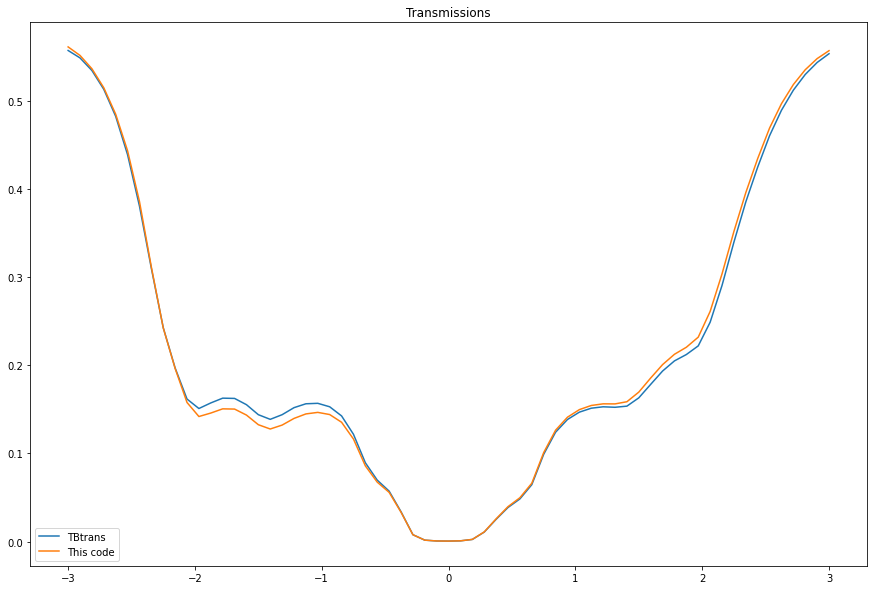

In [103]:
G.Inspect_Transmission(0,1)


In [140]:
#G.reset_all_fits() # Comment in to reset fits!
NL = 5
min_tol  = -0.0*np.ones(NL)
min_tol1 =  min_tol.copy()
min_tol2 =  min_tol.copy()

#ei1 = G.fitted_lorentzians[0].ei.copy(); gi1 = G.fitted_lorentzians[0].gamma.copy()
#ei1 = G.fitted_lorentzians[1].ei.copy(); gi1 = G.fitted_lorentzians[1].gamma.copy()


def run_mini(its):
    G.Fit(fact = 0.8, Fallback_W = 30.0, NumL = NL,
          fit_mode      = 'all',
          force_PSD     = True,
          force_PSD_tol = [min_tol1, min_tol2],
          use_analytical_jac = True,
          min_method = 'SLSQP',
          ebounds = (-4, 4),
          wbounds = (1e-6, 1.3),
          gbounds = (None, None),
          tol = -1,
          options = {'disp':True,'maxiter':its, 
                     'gtol':1e-10,
                     'ftol':1e-10,
                     'iprint':1
                     },
          fit_real_part = False,
          specific_bounds = None,#[{(0 ,2) :[(0.1, 0.11), (4,5)]}, {(0 ,5) :[(-0.1, 0.1), (4,5)]}], 
          alpha_PO = 0.0001, 
          )


In [141]:
run_mini(50)

Finding Lambda matrices:

Rerun


--------------------
Optimizing Lorentzian Expansion
--------------------

Accumulated indices:
[0] [0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 8, 8, 8, 8, 9, 9, 9, 10, 10, 11] [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 3, 4, 5, 6, 7, 8, 9, 10, 11, 4, 5, 6, 7, 8, 9, 10, 11, 5, 6, 7, 8, 9, 10, 11, 6, 7, 8, 9, 10, 11, 7, 8, 9, 10, 11, 8, 9, 10, 11, 9, 10, 11, 10, 11, 11]

Bounds on centers:

((-8, 8), (-8, 8), (-8, 8), (-8, 8), (-8, 8))

Bounds on linewidth:

((0.01, 1.3), (0.01, 1.3), (0.01, 1.3), (0.01, 1.3), (0.01, 1.3))
Iteration limit reached    (Exit mode 9)
            Current function value: 18.58078920643851
            Iterations: 50
            Function evaluations: 540
            Gradient evaluations: 50

Bounds on ce

In [142]:
#G.fitted_lorentzians[0].ei    = G.fitted_lorentzians[1].ei.copy()
#G.fitted_lorentzians[0].gamma[0] = G.fitted_lorentzians[1].gamma[0].copy()
G.pickle('GrainBoundary')


[[1 1 1 1 1 1]
 [1 1 1 1 1 1]
 [1 1 1 1 1 1]
 [1 1 1 1 1 1]
 [1 1 1 1 1 1]
 [1 1 1 1 1 1]]


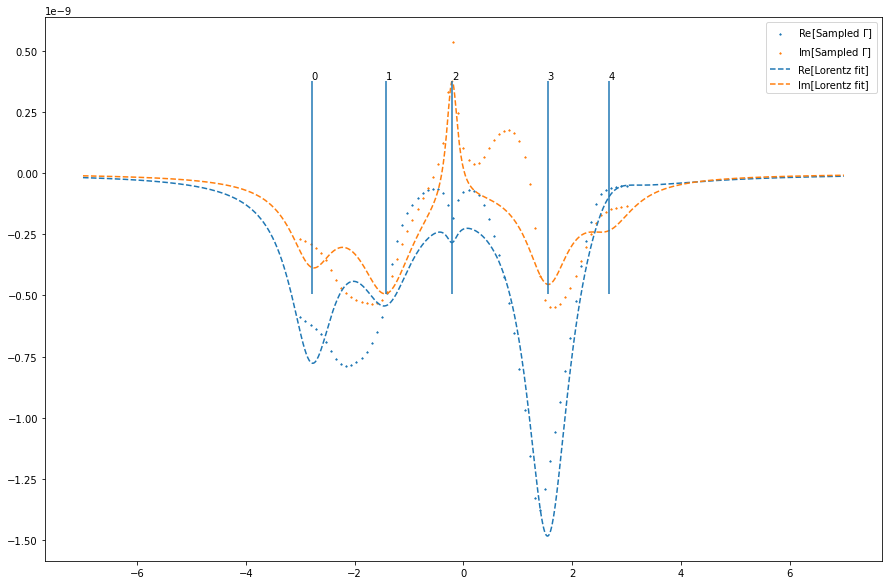

In [148]:
print(G.fitted_lorentzians[1].is_zero)
IK = 2
G.Inspect_Lorentzian_fit(0,0,3,11,6,                          ik = IK, Emin = -7, Emax = 7, center_lines = True)


Minimum distance from Fermi-poles to Lorentzian poles: 0.02253586253267116/n
Minimum distance between Lorentzian poles: 0.7506786145169794/n
Minimum value of imaginary part of Lorentzian poles: 0.13547613562158148


(0.0, 5.0)

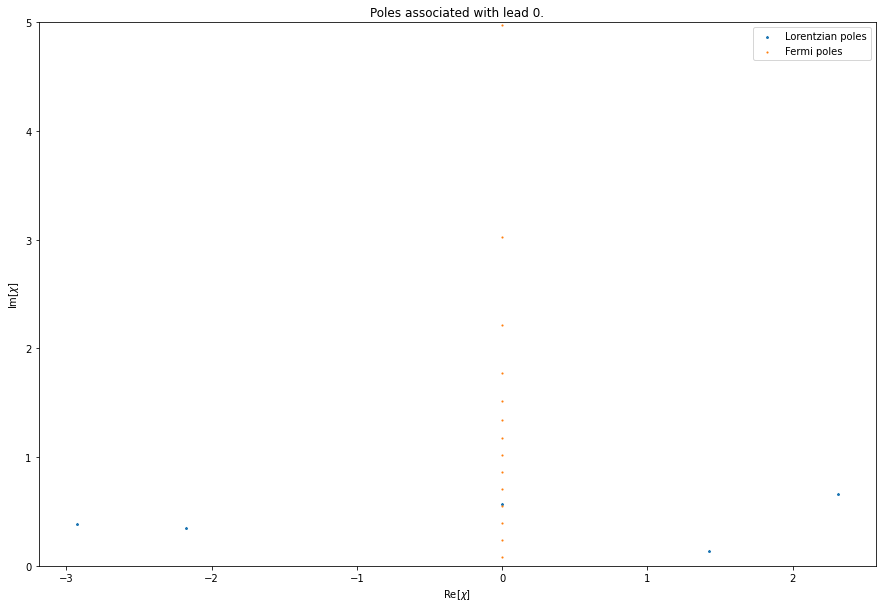

In [150]:
G.Inspect_Poles(0)
plt.ylim([0,5])

In [151]:
G.diagonalise()
G.get_propagation_quantities()
G.get_dense_matrices_purenp(1e-8)
G.Check_input_to_ODE(loose_fermi = True)


Finding eigenvalues and eigenvectors
Maximum of eigenvalues of Lorentzian Gammas: 123.10918
Minimum of eigenvalues of Lorentzian Gammas: -0.0

 Check the ODECheck.txt file lying in the working directory!


 The values in the file should be small!

